In [1]:
import pandas as pd
import numpy as np
import talib as ta
import matplotlib.pyplot as plt
from datetime import datetime
import os
from backtest import backtest, plot_equity ,report
from binance.client import Client

In [ ]:
api_key = os.environ.get('binance_api')
api_secret = os.environ.get('binance_secret')
client = Client(api_key, api_secret)

# ====  設定起始與結束時間（2025年5月～7月） ====
start_str = '2023-07-26 00:00:00'
end_str = '2025-07-27 23:59:59'
start_ts = int(datetime.strptime(start_str, "%Y-%m-%d %H:%M:%S").timestamp() * 1000)
end_ts = int(datetime.strptime(end_str, "%Y-%m-%d %H:%M:%S").timestamp() * 1000)
bars = client.get_historical_klines('BTCUSDT', '5m', start_ts, end_ts)

with open('15min.csv', 'w', newline='') as f:
    for line in bars:
        del line[6:]
    df = pd.DataFrame(bars, columns=['date', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df['seconds'] = np.floor_divide(df['date'], 1000)
    df['date'] = df['seconds'].apply(lambda x: datetime.fromtimestamp(x).strftime('%Y-%m-%d %H:%M:%S'))
    df.set_index('date', inplace=True)
    print(df.head()) 
    df.to_csv('15min.csv')

                               Open            High             Low  \
date                                                                  
2023-07-26 00:00:00  29181.50000000  29196.28000000  29181.50000000   
2023-07-26 00:05:00  29196.27000000  29225.07000000  29196.27000000   
2023-07-26 00:10:00  29225.07000000  29251.41000000  29225.06000000   
2023-07-26 00:15:00  29249.83000000  29295.76000000  29236.84000000   
2023-07-26 00:20:00  29290.71000000  29290.71000000  29253.91000000   

                              Close        Volume     seconds  
date                                                           
2023-07-26 00:00:00  29196.28000000   66.36870000  1690300800  
2023-07-26 00:05:00  29225.07000000   95.38690000  1690301100  
2023-07-26 00:10:00  29249.84000000  124.22095000  1690301400  
2023-07-26 00:15:00  29290.71000000  158.90763000  1690301700  
2023-07-26 00:20:00  29256.00000000   68.80596000  1690302000  


In [ ]:
# ===== 參數 =====
DMI_LEN = 14
ADX_EXIT_TH = 20                
# =================

# ---------- 讀資料 ----------
df = pd.read_csv('15min.csv', index_col=0, parse_dates=True)
df = df[['High', 'Low', 'Open', 'Close', 'Volume']].astype(float).sort_index()

# 交叉
def crossover(a,b): return (a > b) & (a.shift(1) <= b.shift(1))
def crossdown(a,b): return (a < b) & (a.shift(1) >= b.shift(1))

====== 回測報告 (Vegas + DMI/ADX ======
資料根數: 70,368 | 估計週期: 15.00 分/根
交易次數: 101
總報酬率: 19.88%
CAGR年化: 9.45%
Sharpe  : 0.59
最大回撤: -23.74%
勝率: 19.80%
單邊費用 : 0.050%


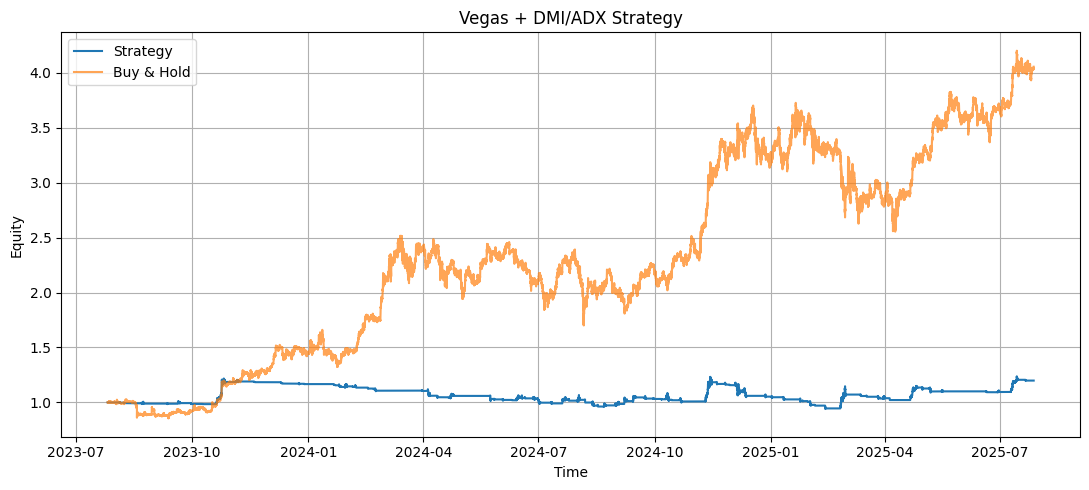

In [ ]:
#策略1 - Vegas + DMI/ADX
ema12  = ta.EMA(df['Close'], timeperiod=12)
ema144 = ta.EMA(df['Close'], timeperiod=144)
ema169 = ta.EMA(df['Close'], timeperiod=169)
ema576 = ta.EMA(df['Close'], timeperiod=576)
ema676 = ta.EMA(df['Close'], timeperiod=676)

plusDI  = ta.PLUS_DI(df['High'], df['Low'], df['Close'], timeperiod=14)
minusDI = ta.MINUS_DI(df['High'], df['Low'], df['Close'], timeperiod=14)
adx     = ta.ADX(df['High'], df['Low'], df['Close'], timeperiod=14)

vegasLong  = np.minimum(ema144, ema169) > np.maximum(ema576, ema676)
vegasShort = np.minimum(ema144, ema169) < np.maximum(ema576, ema676)

long_entry  = vegasLong  & crossover(df['Close'], ema144) & (ema12 > ema144) & (plusDI > minusDI)
short_entry = vegasShort & crossdown(df['Close'], ema144) & (ema12 < ema144) & (plusDI < minusDI)
long_exit   = (adx < 20) & (ema12 < ema144)
short_exit  = (adx < 20) & (ema12 > ema144)

# 回測（把條件與費率、步長丟進去）
df_bt, stats = backtest(
    df=df,
    long_entry=long_entry,
    long_exit=long_exit,
    short_entry=short_entry,
    short_exit=short_exit,
    fee_per_side=0.0005,   # 單邊 0.05%
    step_sec=15*60.0       # 15 分K
)

# 印結果
report(stats, name="回測報告 (Vegas + DMI/ADX")

# 畫圖
plot_equity(df_bt, title="Vegas + DMI/ADX Strategy")